In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("data/breast_cancer_clean.csv", index_col=0)
X = df.drop("diagnosis", axis=1).values
y = df["diagnosis"].map({"M": 1, "B": 0}).values


In [3]:

scaler = StandardScaler()
X = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2
                                                    , stratify=y, random_state=42)

In [4]:
k = 2  
kmeans = KMeans(n_clusters=k, random_state=42)
X_train_dist = kmeans.fit_transform(X_train)

idxs = np.argmin(X_train_dist, axis=0)
X_representatives = X_train[idxs]
y_representatives = y_train[idxs]

print("Representativos:", X_representatives.shape)

Representativos: (2, 30)


In [5]:
log_reg2 = LogisticRegression(max_iter=5000, random_state=42)
log_reg2.fit(X_representatives, y_representatives)

print("Precisión usando representativos:", log_reg2.score(X_test, y_test))

Precisión usando representativos: 0.8859649122807017


In [6]:
log_reg_random = LogisticRegression(max_iter=5000, random_state=42)
log_reg_random.fit(X_train[:2], y_train[:2])

print("Precisión usando aleatorios:", log_reg_random.score(X_test, y_test))

Precisión usando aleatorios: 0.8157894736842105


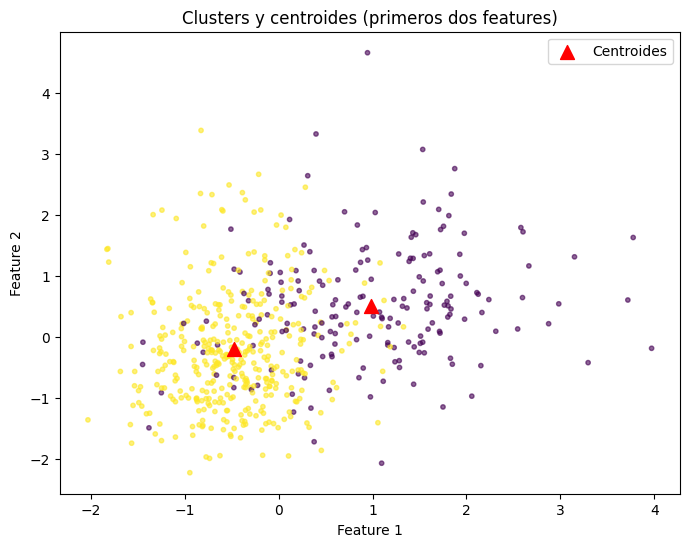

In [7]:
import matplotlib.pyplot as plt

pred = kmeans.predict(X)
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=pred, cmap='viridis', s=10, alpha=0.6)
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], marker='^', c='red', s=100, label='Centroides')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Clusters y centroides (primeros dos features)')
plt.legend()
plt.show()

In [8]:
from sklearn.metrics import silhouette_score
labels = kmeans.labels_
silhouette_avg = silhouette_score(X_train, labels)
print("Coeficiente de silueta:", silhouette_avg)

Coeficiente de silueta: 0.35065378261461005


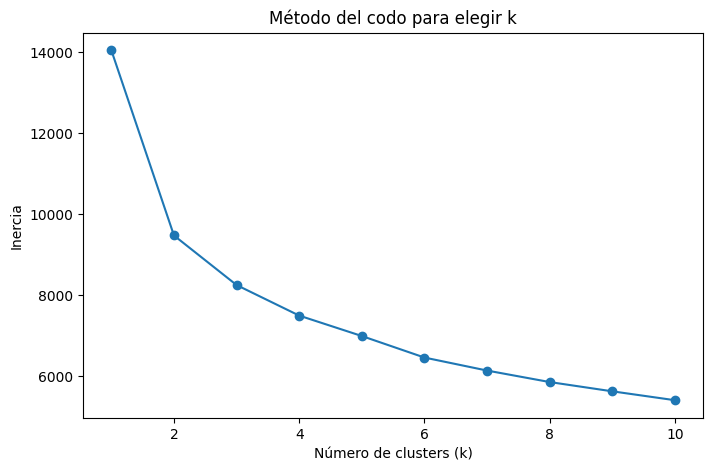

In [9]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_train)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del codo para elegir k')
plt.show()

#### Ejemplo con datos sinteticos K-Means


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import random

# Número aleatorio de centros entre 1 y 20

# n_centers = random.randint(1, 20)
n_centers = 20

# Generar centros aleatorios separados adecuadamente
blob_centers = []
while len(blob_centers) < n_centers:
    candidate = np.random.uniform(-10, 10, size=2)
    if all(np.linalg.norm(candidate - center) > 2 for center in blob_centers):
        blob_centers.append(candidate)

blob_centers = np.array(blob_centers)
blob_std = np.full(n_centers, 1.0)  # desviación estándar uniforme dispersion
# Cada cluster tendrá una desviación estándar de 1.0 alrededor de su centroide.
#blob_std = [0.5, 1.0, 2.0, 3.0, 5.0]



from sklearn.datasets import make_blobs
#X, y = make_blobs(n_samples=1000, centers=blob_centers, cluster_std=blob_std, random_state=42)

X, y = make_blobs(n_samples=10000, centers=blob_centers,
                  cluster_std=blob_std, random_state=42)




#print(f"Se generaron {n_centers} clusters con {'X' if fix_x else 'Y'} fijo en {fixed_value}")
print(f"Se generaron {n_centers}")

print("Coordenadas de los centroides:")
print(blob_centers)


Se generaron 20
Coordenadas de los centroides:
[[-6.048387    6.79189712]
 [-8.89212113  8.77268281]
 [ 1.5442972  -2.14698336]
 [-4.76253289  9.91274827]
 [-8.87825133 -5.19889125]
 [-6.85859339  4.88689526]
 [-9.31103151  2.98715071]
 [ 8.46973293 -8.75774838]
 [ 8.05238206 -1.18228033]
 [-6.01020446 -6.16244252]
 [-6.32616301 -3.75409895]
 [-3.07750428  4.38791978]
 [ 4.930523   -5.9336401 ]
 [ 6.36072988  4.63828562]
 [ 2.8915706   2.11790536]
 [ 2.95354234  6.69240197]
 [-1.81147671  9.02645998]
 [ 8.25020595  8.30557747]
 [-1.46964715 -6.15820629]
 [-4.88604234 -0.50599728]]


In [11]:
import matplotlib.pyplot as plt

def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)

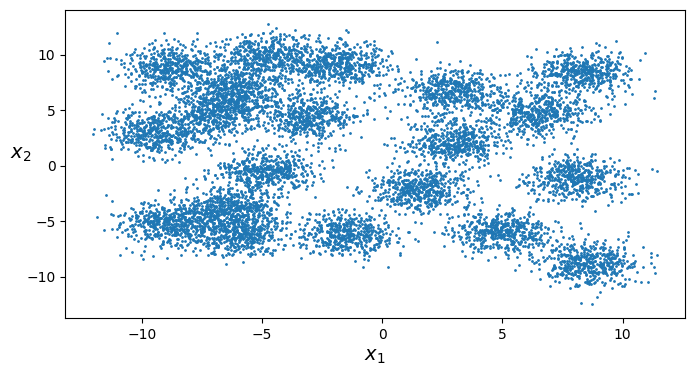

In [12]:
plt.figure(figsize=(8, 4))
plot_clusters(X)
plt.show()

In [13]:
from sklearn.cluster import KMeans
# k = len(blob_centers)
k = 20
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)
y_pred         #devolver las etiques de cada grupo y

array([13,  0,  1, ...,  1, 16, 16], shape=(10000,), dtype=int32)

In [14]:
kmeans.cluster_centers_  # centro de los clusters

array([[ 6.46533973,  4.70171866],
       [-6.24355324, -3.67937426],
       [-6.89153596,  4.69125291],
       [ 8.5717877 , -8.81173326],
       [ 8.27445822,  8.38458288],
       [-1.77555207,  9.10504467],
       [-8.85939093,  8.86664302],
       [-4.81535515, -0.42791703],
       [ 1.53868756, -2.15777047],
       [ 2.85636001,  6.75360489],
       [ 8.02704561, -1.13081996],
       [-8.93763278, -5.23503596],
       [-9.44807153,  2.92657492],
       [-3.04670235,  4.39845737],
       [-5.93894928, -6.29537002],
       [ 4.96798285, -5.97539172],
       [-1.46274471, -6.18765256],
       [-4.81578859, 10.03945713],
       [ 2.98332186,  2.12105367],
       [-5.99611406,  7.03605364]])

In [15]:
X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])  #Predecir nuevas ubicaciones
kmeans.predict(X_new)

array([18, 18, 13, 13], dtype=int32)

In [16]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=10, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=10,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)

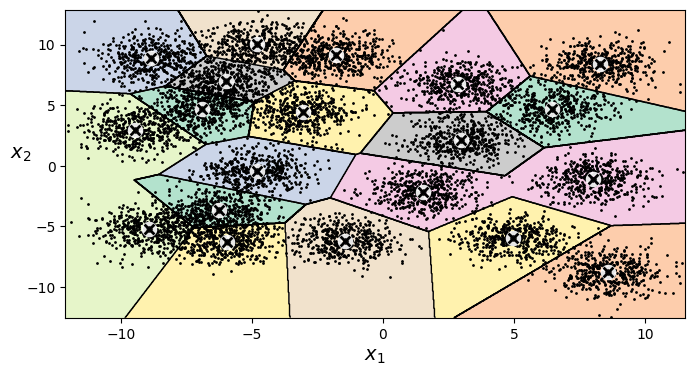

In [17]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)
plt.show()

In [18]:
kmeans.transform(X_new)  # la  distancia de cada punto del X_neww

array([[ 7.00713219,  8.44021617,  7.39838564, 13.79743166, 10.45129453,
         7.32354046, 11.20890691,  5.39281247,  4.43335253,  5.54576884,
         8.61600225, 11.49900105,  9.49339753,  3.87749829, 10.20217047,
         9.39615489,  8.31728781,  9.37148284,  2.98577684,  7.83040357],
       [ 4.39407136, 10.84889711, 10.2511134 , 12.16299282,  8.28147379,
         8.56081522, 13.70386586,  8.18379846,  4.40709534,  4.75577459,
         5.92226487, 13.95896922, 12.4825088 ,  6.505014  , 12.19499807,
         8.21461074,  9.32489918, 11.21246727,  0.12219718, 10.30979653],
       [ 9.61709429,  7.42527293,  4.24315785, 16.53551672, 12.49428433,
         6.22662374,  8.29155971,  3.87893407,  6.87039162,  6.9560407 ,
        11.77537296, 10.15240367,  6.44848957,  1.39923698,  9.74891412,
        12.00193348,  9.31536974,  7.26987241,  6.04753563,  5.02657224],
       [ 9.71803587,  6.97891853,  4.46605435, 16.18213768, 12.71777197,
         6.7175805 ,  8.65254907,  3.44502721,  

In [19]:

# kmeans_iter1 = KMeans(n_clusters=5, init="random", n_init=1,
#                      algorithm="full", max_iter=1, random_state=1)
# kmeans_iter1 = KMeans(n_clusters=5, init="random", n_init=1,
#                      algorithm="lloyd", max_iter=1, random_state=1)
# kmeans_iter1 = KMeans(n_clusters=5, init="random", n_init=5,
#                      algorithm="elkan", max_iter=1, random_state=1)
# Configuración del modelo K-Means con inicialización inteligente
kmeans_iter1 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                      algorithm="elkan", max_iter=3, random_state=1)
# kmeans_iter2 = KMeans(n_clusters=5, init="random", n_init=1,
#                      algorithm="full", max_iter=2, random_state=1)
# kmeans_iter2 = KMeans(n_clusters=5, init="random", n_init=5,
#                      algorithm="elkan", max_iter=2, random_state=1)
kmeans_iter2 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                     algorithm="elkan", max_iter=2, random_state=1)

# kmeans_iter3 = KMeans(n_clusters=5, init="random", n_init=1,
#                      algorithm="full", max_iter=3, random_state=1)
# kmeans_iter3 = KMeans(n_clusters=5, init="random", n_init=5,
#                      algorithm="elkan", max_iter=3, random_state=1)
kmeans_iter3 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                     algorithm="elkan", max_iter=1, random_state=1)
kmeans_iter1.fit(X)
kmeans_iter2.fit(X)
kmeans_iter3.fit(X)

,n_clusters,20
,init,'k-means++'
,n_init,1
,max_iter,1
,tol,0.0001
,verbose,0
,random_state,1
,copy_x,True
,algorithm,'elkan'


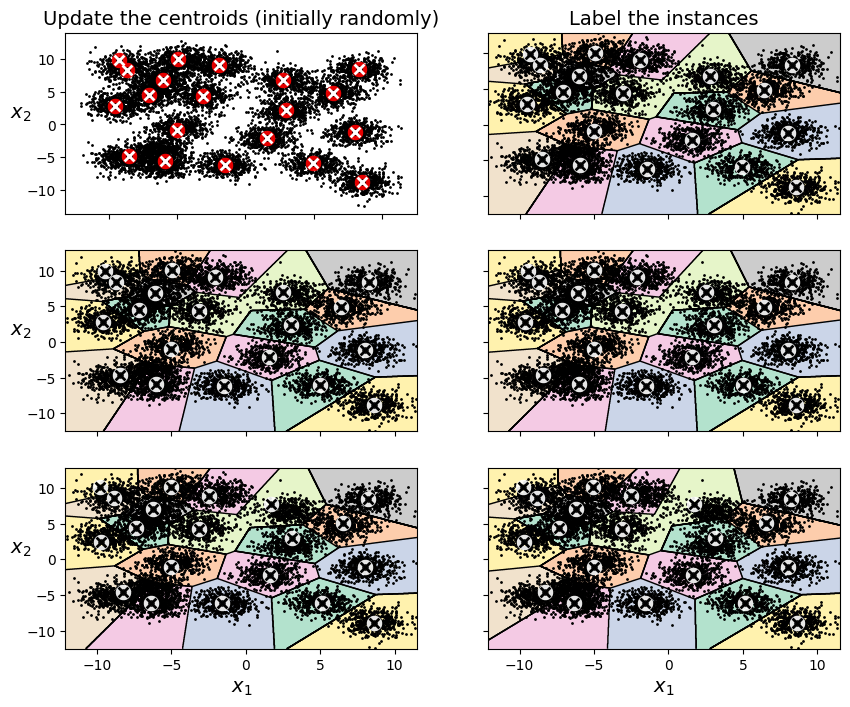

In [20]:
plt.figure(figsize=(10, 8))

plt.subplot(321)
plot_data(X)
plot_centroids(kmeans_iter1.cluster_centers_, circle_color='r', cross_color='w')
plt.ylabel("$x_2$", fontsize=14, rotation=0)
plt.tick_params(labelbottom=False)
plt.title("Update the centroids (initially randomly)", fontsize=14)

plt.subplot(322)
plot_decision_boundaries(kmeans_iter1, X, show_xlabels=False, show_ylabels=False)
plt.title("Label the instances", fontsize=14)

plt.subplot(323)
plot_decision_boundaries(kmeans_iter1, X, show_centroids=False, show_xlabels=False)
plot_centroids(kmeans_iter2.cluster_centers_)

plt.subplot(324)
plot_decision_boundaries(kmeans_iter2, X, show_xlabels=False, show_ylabels=False)

plt.subplot(325)
plot_decision_boundaries(kmeans_iter2, X, show_centroids=False)
plot_centroids(kmeans_iter3.cluster_centers_)


plt.subplot(326)
plot_decision_boundaries(kmeans_iter3, X, show_ylabels=False)

plt.show()

In [21]:
def plot_clusterer_comparison(clusterer1, clusterer2, X, title1=None, title2=None):
    clusterer1.fit(X)
    clusterer2.fit(X)

    plt.figure(figsize=(10, 3.2))

    plt.subplot(121)
    plot_decision_boundaries(clusterer1, X)
    if title1:
        plt.title(title1, fontsize=14)

    plt.subplot(122)
    plot_decision_boundaries(clusterer2, X, show_ylabels=False)
    if title2:
        plt.title(title2, fontsize=14)

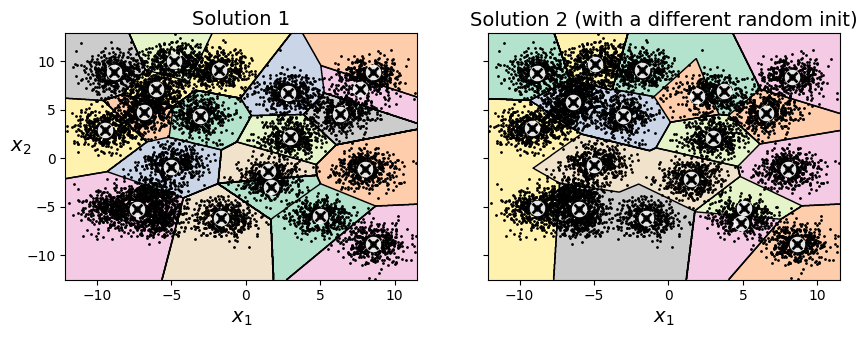

In [22]:
kmeans_rnd_init1 = KMeans(n_clusters=k, init="random", n_init=1,
                         algorithm="elkan", random_state=11)
kmeans_rnd_init2 = KMeans(n_clusters=k, init="random", n_init=1,
                         algorithm="elkan", random_state=19)

plot_clusterer_comparison(kmeans_rnd_init1, kmeans_rnd_init2, X,"Solution 1", "Solution 2 (with a different random init)")

plt.show()

In [23]:
kmeans_rnd_10_inits = KMeans(n_clusters=k, init="random", n_init=10,
                              algorithm="elkan", random_state=11)        # inicializando 10 y quedandome con el mejor resultado
kmeans_rnd_10_inits.fit(X)

,n_clusters,20
,init,'random'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,11
,copy_x,True
,algorithm,'elkan'


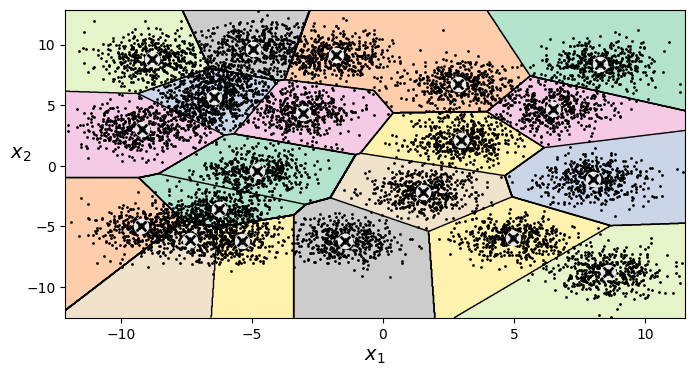

In [24]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans_rnd_10_inits, X)
plt.show()

In [25]:
from sklearn.metrics import silhouette_score
silhouette_score(X, kmeans.labels_)

0.4937009847877598

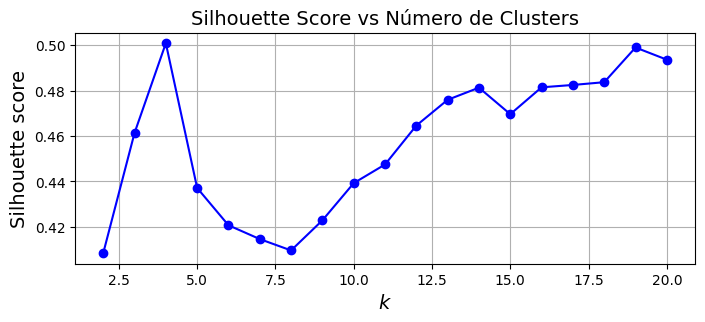

In [26]:

import matplotlib.pyplot as plt

# Definir máximo valor de k
max_k = min(20, len(blob_centers))

# Entrenar un modelo KMeans para cada k de 1 hasta max_k
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X) for k in range(1, max_k + 1)]

# Calcular silhouette_scores para k ≥ 2
silhouette_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k[1:]]

# Generar eje x para k de 2 hasta max_k
ks = list(range(2, max_k + 1))

# Graficar
plt.figure(figsize=(8, 3))
plt.plot(ks, silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.title("Silhouette Score vs Número de Clusters", fontsize=14)
plt.grid(True)
plt.show()


ValueError: num must be an integer with 1 <= num <= 4, not 5

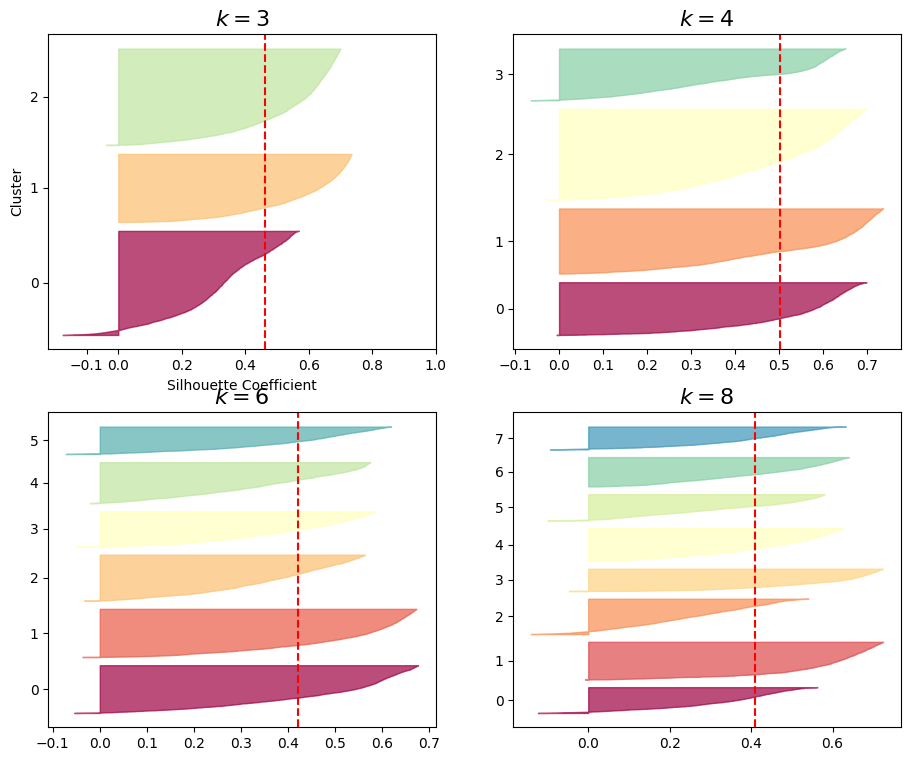

In [ ]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib as mpl

plt.figure(figsize=(11, 9))

valid_ks = [k for k in (3,4,6,8,10,12,15,20) if k <= len(kmeans_per_k)]  # Filtrar solo los ks válidos
n_plots = len(valid_ks)
n_rows = (n_plots + 1) // 2 if n_plots > 1 else 1

for plot_idx, k in enumerate(valid_ks):
    plt.subplot(n_rows, 2, plot_idx + 1)
    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    if k in (3, 5):
        plt.ylabel("Cluster")

    plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.xlabel("Silhouette Coefficient")

    if k - 2 < len(silhouette_scores):
        plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title(f"$k={k}$", fontsize=16)

plt.tight_layout()
plt.show()